In [1]:
import pandas as pd
import numpy as np

# **Load Dataset**

In [2]:
df = pd.read_csv("retail_sales_dataset.csv")

# **Inspection of the dataset**

In [3]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


# **Handling Missing Values**

In [4]:
df.isnull().sum()


,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


Converting Date Column for Time Series Analysis

In [5]:
df['Date'] = pd.to_datetime(df['Date'])

# **Descriptive Analysis**

In [7]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [13]:
df[['Age','Quantity','Price per Unit','Total Amount']].mode()


,Age,Quantity,Price per Unit,Total Amount
0,43,4.0,50.0,50.0
1,64,NaN,NaN,NaN


In [14]:
df[['Age','Quantity','Price per Unit','Total Amount']].median()


,0
Age,42.0
Quantity,3.0
Price per Unit,50.0
Total Amount,135.0


# **Time Series Analysis**

In [15]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [16]:
monthly_sales = df.groupby('Month')['Total Amount'].sum()

<Axes: title={'center': 'Monthly Sales Trend'}, xlabel='Month'>

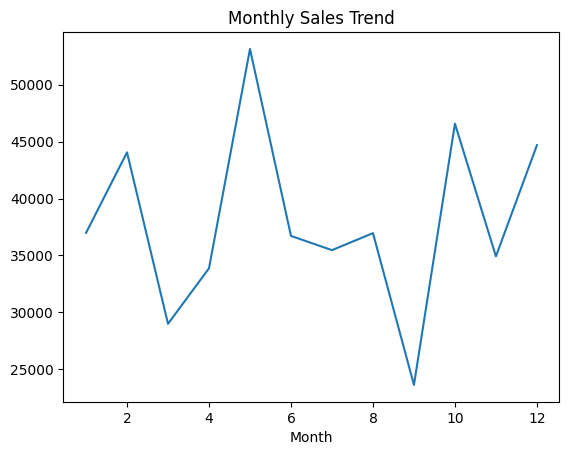

In [19]:
monthly_sales.plot(kind='line', title='Monthly Sales Trend')


# **Customer Analysis**

<Axes: title={'center': 'Age Distribution'}, ylabel='Frequency'>

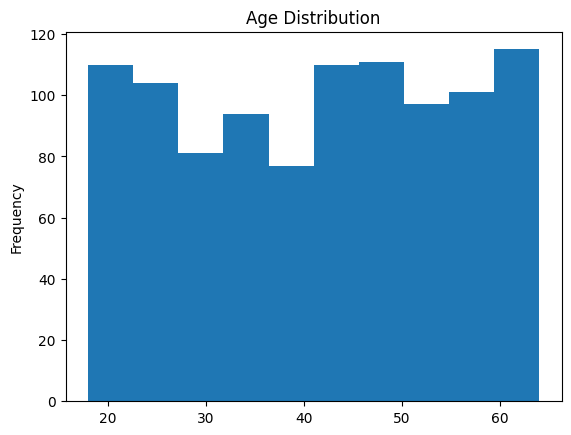

In [25]:
df['Age'].plot(kind='hist', title='Age Distribution')


<Axes: xlabel='Gender'>

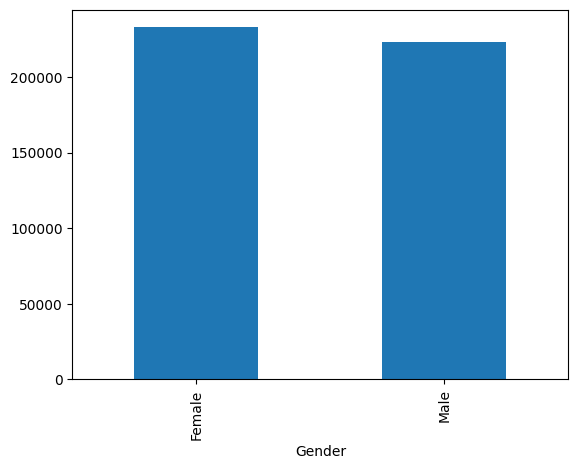

In [26]:
df.groupby('Gender')['Total Amount'].sum().plot(kind='bar')


# **Category wise sales**

<Axes: title={'center': 'Sales by Product Category'}, xlabel='Product Category'>

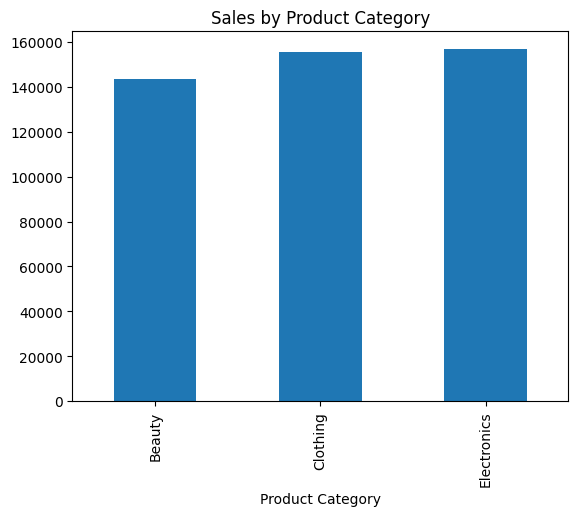

In [30]:
category_sales = df.groupby('Product Category')['Total Amount'].sum()
category_sales.plot(kind='bar', title='Sales by Product Category')


# **Purchase** **Behaviour**

<Axes: xlabel='Quantity', ylabel='Total Amount'>

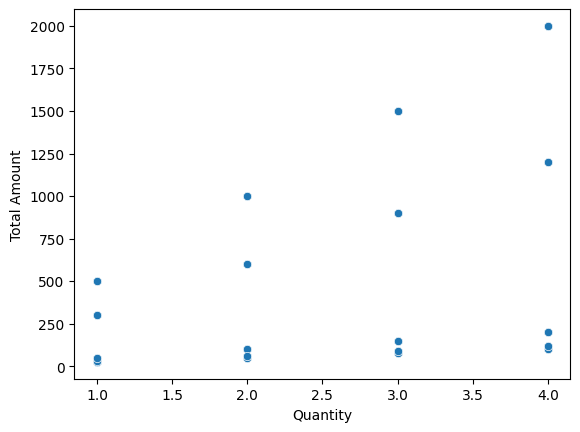

In [31]:
import seaborn as sns
sns.scatterplot(x='Quantity', y='Total Amount', data=df)


# **Outlier** **Detection**

<Axes: ylabel='Total Amount'>

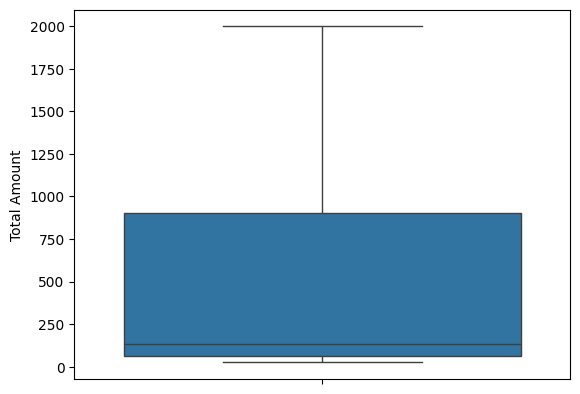

In [32]:
sns.boxplot(df['Total Amount'])


# **Correlation Analysis**

In [34]:
df[['Age','Quantity','Price per Unit','Total Amount']].corr()


,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


<Axes: >

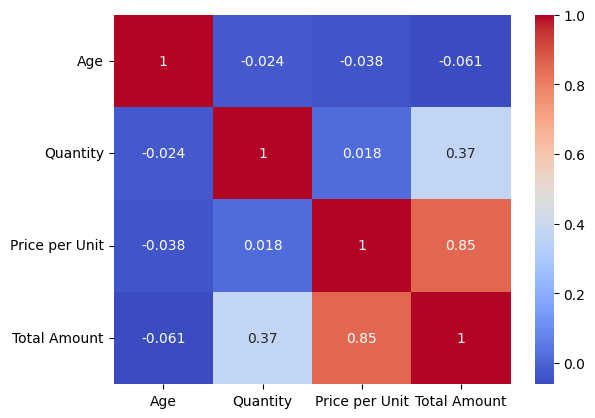

In [36]:
sns.heatmap(
    df[['Age','Quantity','Price per Unit','Total Amount']].corr(),
    annot=True, cmap='coolwarm'
)
